# Project 2: Reproducibility in Natural Language Processing



### Read Data

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-dark') 

In [2]:
sou = pd.read_csv("data/SOTU.csv")

### Processing Speeches with SpaCy

In [3]:
import spacy
from tqdm import tqdm
from collections import Counter

nlp = spacy.load("en_core_web_sm")

### Common Words

#### Common Words per Year Function

In [4]:
def get_most_common_words(df, year, n=25):
    """
    Processes the SOTU speech for a given year and returns
    the most common non-stopword/punctuation lemmas.
    """

    # Step 1: Subset df
    subset_df = df[df["Year"]==int(year)]

    # Step 2: Process the text with spaCy
    speeches = []
    for speech in subset_df["Text"]:
        speech_tokens = nlp(speech)
        speeches.append(speech_tokens)
    
    # Step 3: Get lemmas
    lemmas = []
    for speech in speeches:
        for token in speech:
            if (token.is_stop==False) & (token.is_punct==False) & (token.is_space==False) & (len(token)>2):
                lemma = token.lemma_
                lemmas.append(lemma.lower())
    top_lemmas = Counter(lemmas).most_common(n)
    
    return top_lemmas

In [17]:
# Subset to 2000 onwards
sou2k = sou[sou["Year"] > 1999]

# Top 10 words saved in dictionary for each year
dfs = {}
for year in sou2k["Year"]:
    words = get_most_common_words(sou2k, year, n=10)
    dfs[year] = pd.DataFrame(words)
    dfs[year].columns = ["Word", "Count"]

[('year', 64),
 ('child', 56),
 ('new', 47),
 ('ask', 46),
 ('work', 44),
 ('help', 44),
 ('people', 41),
 ('america', 33),
 ('thank', 33),
 ('want', 28)]

### Exploratory Data Analysis of Word Frequencies Over Time

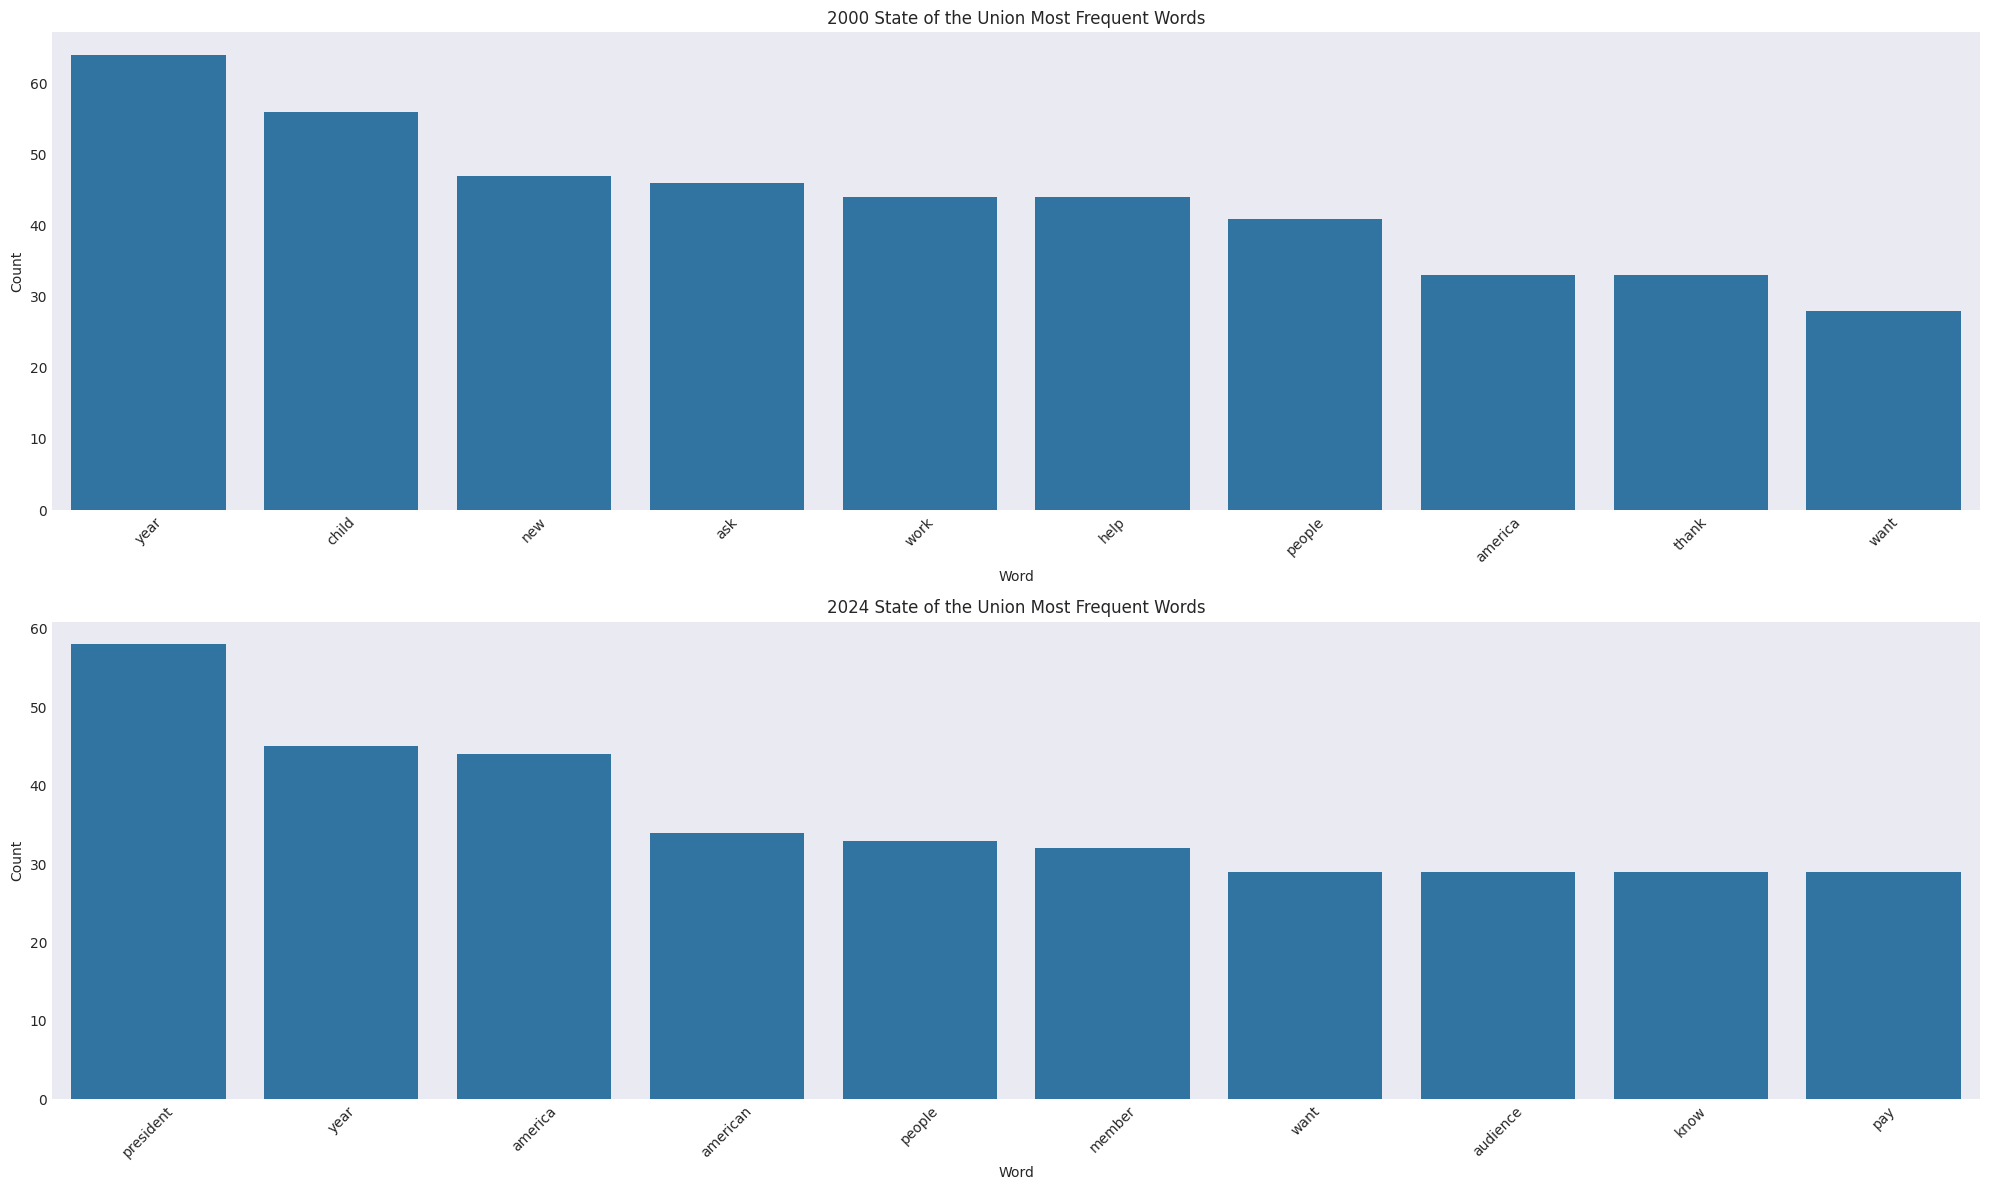

In [13]:
# Bar plots for 2000 and 2024
fig, axes = plt.subplots(2, 1, figsize=(20, 12))

# 2000
sns.barplot(data=dfs[2000], x="Word", y="Count", ax=axes[0])
axes[0].set_title("2000 State of the Union Most Frequent Words")
axes[0].tick_params(axis="x", rotation=45)

# 2024
sns.barplot(data=dfs[2024], x="Word", y="Count", ax=axes[1])
axes[1].set_title("2024 State of the Union Most Frequent Words")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
# plt.savefig(outputs_dir / "2000_2024_sou_frequent_words.png", dpi=300, bbox_inches="tight")
plt.show();

### Commentary

Absense of "president" stands out in 2000: may be worth investigating further. Pay and America also seem like viable candidates for analysis.

### Frequency of Selected Words Over Time

In [23]:
def count_words(df, year, words):
   
    # Step 1: Subset df
    subset_df = df[df["Year"]==int(year)]

    # Step 2: Process the text with spaCy
    speeches = []
    for speech in subset_df["Text"]:
        speech_tokens = nlp(speech)
        speeches.append(speech_tokens)
    
    # Step 3: Get lemmas
    lemmas = []
    for speech in speeches:
        for token in speech:
            if (token.is_stop==False) & (token.is_punct==False) & (token.is_space==False) & (len(token)>2):
                lemma = token.lemma_
                lemmas.append(lemma.lower())
    count_lemmas = Counter(lemmas)

    new_df = {"Word": words, "Count": []}
    for word in words:
        new_df["Count"].append(count_lemmas[word])
    
    return pd.DataFrame(new_df)

In [24]:
words = ["president", "america", "pay"]
count_words(sou2k, 2000, words)

,Word,Count
0,president,10
1,america,33
2,pay,12


In [ ]:
sns.line

## Part 4: Choose your own advecnture! (7 Points; Optional for Extra Credit)

This section is open ended and your chance to explare any advanced analysis. Please perform any additional analysis you find interesting! Suggested analyses (only do one max):

- Topic evolution over time - see https://maartengr.github.io/BERTopic/getting_started/topicsovertime/topicsovertime.html#visualization 
- Word frequency over time - does the frequency of certain words change over time
- Semantic similarity - investigate similarity within and between presidents or time periods. For example, similarity between one presidents speeches, e.g. are all of Biden's speeches similar to each other? How similar are they to Trump's speeches? Are speeches from the 2000s more similar to each other than speeches in the 1800s? Which two presidents have the most similar speeches? See https://spacy.io/usage/linguistic-features#vectors-similarity 
-  Named Entity Recognition - which entity types are most common in speeches? What are the most common words for each entity type - see https://spacy.io/usage/linguistic-features#named-entities 
- Classification - can you build a classifier to detect democratic versus republican state of the union speeches from 1980-2024 - see https://scikit-learn.org/stable/auto_examples/text/plot_document_classification_20newsgroups.html#sphx-glr-auto-examples-text-plot-document-classification-20newsgroups-py 
